Observaciones: 720 cuencas | Variables: 17

Estadísticas descriptivas:
       escurrimiento  uso_agricola  concesionado       Ev  disponibilidad
count         720.00        720.00        720.00   720.00          720.00
mean          437.47        258.19       1226.29    12.20          394.15
std          1017.62       1322.15       4467.01    71.42         1290.28
min             0.00          0.00       -120.70     0.00        -1635.39
25%            43.50          0.49         35.81     0.00            3.60
50%           131.65          5.40        157.44     0.00           38.65
75%           414.02         39.11        582.49     0.00          200.92
max         14623.15      15613.25      58740.06  1405.80        12199.91


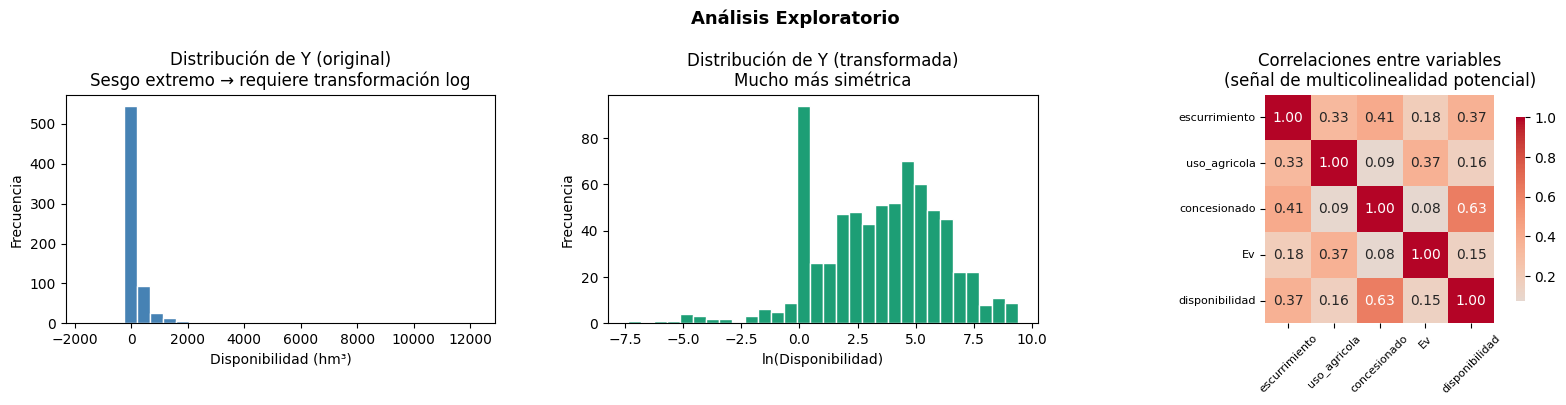


VIF — Modelo inicial:
            Variable        VIF
0  log_escurrimiento  17.390641
2   log_concesionado  15.668584
1       log_agricola   3.595403
4             log_ev   1.771535
3                Rxy   1.220426

VIF — Modelo corregido (sin log_escurrimiento):
           Variable       VIF
1      log_agricola  3.359897
0  log_concesionado  2.628273
3            log_ev  1.649152
2               Rxy  1.159468
                            OLS Regression Results                            
Dep. Variable:               log_disp   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     425.3
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:14:19   Log-Likelihood:                -1264.7
No. Observations:                 720   AIC:                             2609.
Df Residuals:                    

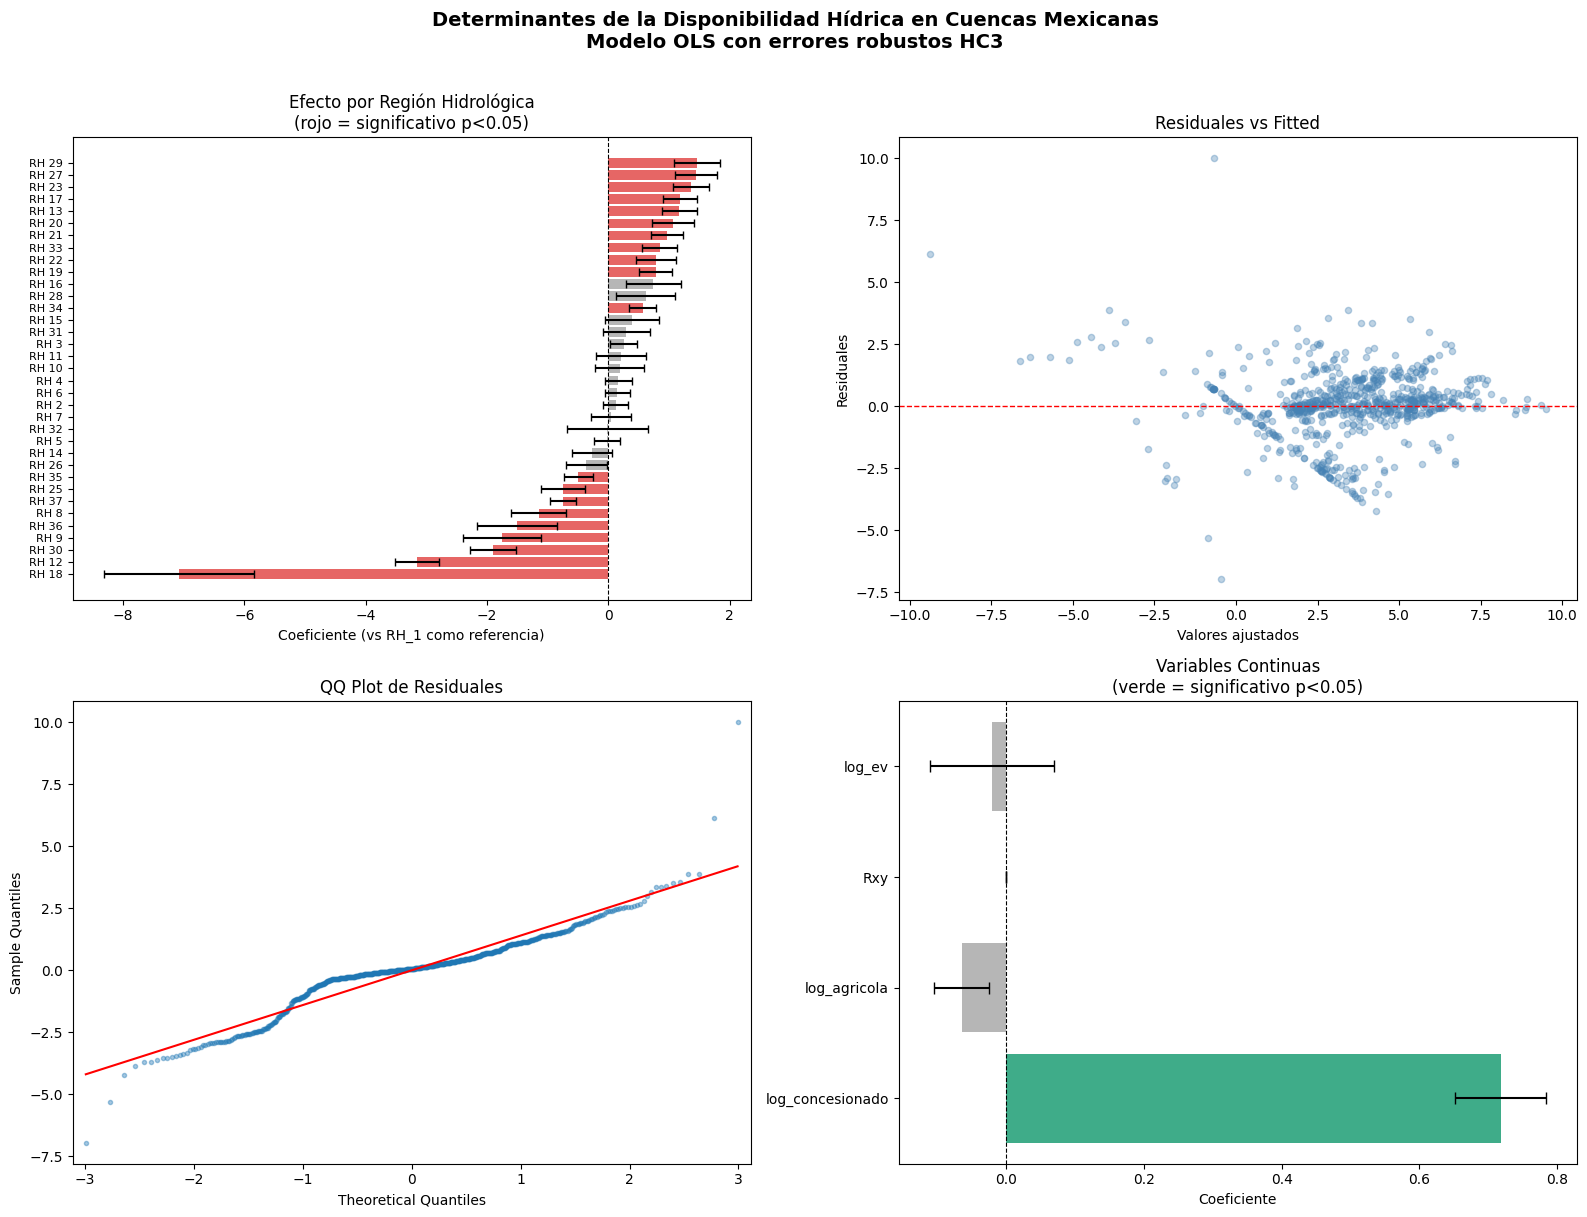


RESUMEN EJECUTIVO DEL MODELO
Variable dependiente : ln(Disponibilidad hídrica)
Observaciones : 720 cuencas hidrológicas
R² ajustado : 0.716
F-statistic p-value : 0.00e+00

Variables significativas (p < 0.05):
  log_concesionado          β=+0.718   p=0.000
  RH_8                      β=-1.146   p=0.012
  RH_9                      β=-1.757   p=0.007
  RH_12                     β=-3.152   p=0.000
  RH_13                     β=+1.173   p=0.000
  RH_17                     β=+1.182   p=0.000
  RH_18                     β=-7.087   p=0.000
  RH_19                     β=+0.785   p=0.004
  RH_20                     β=+1.069   p=0.002
  RH_21                     β=+0.966   p=0.000
  RH_22                     β=+0.788   p=0.018
  RH_23                     β=+1.365   p=0.000
  RH_25                     β=-0.747   p=0.040
  RH_27                     β=+1.450   p=0.000
  RH_29                     β=+1.464   p=0.000
  RH_30                     β=-1.903   p=0.000
  RH_33                     β=+0.846  

In [93]:
# =============================================================================
# DETERMINANTES DE LA DISPONIBILIDAD HÍDRICA EN CUENCAS MEXICANAS
# Fuente: CONAGUA — Sistema Nacional de Información del Agua (SINA)
# Método: OLS con errores robustos HC3
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =============================================================================
# 1. CARGA Y LIMPIEZA
# =============================================================================

df = pd.read_csv('Disponibilidad_agua.csv', encoding='latin-1')

# Renombrar columnas para mayor legibilidad
df = df.rename(columns={
    'R H'  : 'region',
    'Cp'   : 'escurrimiento',
    'Uc(a)': 'uso_agricola',
    'Uc(b)': 'uso_pecuario',
    'Uc(c)': 'uso_domestico',
    'Ev '  : 'Ev',            # el CSV original tiene espacio en el nombre
    'Ab'   : 'concesionado',
    'D'    : 'disponibilidad',
    'Clasificación': 'clasificacion'
})

# Eliminar filas con nulos (12 de 732 — 1.6% del total, no introduce sesgo relevante)
df = df.dropna()

print(f"Observaciones: {df.shape[0]} cuencas | Variables: {df.shape[1]}")
print(f"\nEstadísticas descriptivas:")
print(df[['escurrimiento', 'uso_agricola', 'concesionado', 'Ev', 'disponibilidad']].describe().round(2))

# =============================================================================
# 2. EDA
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Análisis Exploratorio', fontsize=13, fontweight='bold')

# --- Distribución de Y antes de transformar ---
axes[0].hist(df['disponibilidad'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Disponibilidad (hm³)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Y (original)\nSesgo extremo → requiere transformación log')

# --- Distribución de Y después de transformar ---
log_disp_preview = np.sign(df['disponibilidad']) * np.log1p(np.abs(df['disponibilidad']))
axes[1].hist(log_disp_preview, bins=30, color='#1D9E75', edgecolor='white')
axes[1].set_xlabel('ln(Disponibilidad)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Y (transformada)\nMucho más simétrica')

# --- Matriz de correlaciones ---
vars_corr = ['escurrimiento', 'uso_agricola', 'concesionado', 'Ev', 'disponibilidad']
corr = df[vars_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[2], square=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Correlaciones entre variables\n(señal de multicolinealidad potencial)')
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('eda_cuencas.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. TRANSFORMACIONES LOGARÍTMICAS
# =============================================================================
# Se usa signed log para variables con valores negativos (concesionado, disponibilidad)
# y log1p para variables con ceros pero sin negativos

df['log_disp'] = np.sign(df['disponibilidad']) * np.log1p(np.abs(df['disponibilidad']))
df['log_agricola'] = np.log1p(df['uso_agricola'])
df['log_concesionado'] = np.sign(df['concesionado'])   * np.log1p(np.abs(df['concesionado']))
df['log_ev'] = np.log1p(df['Ev'])

# Dummies de región hidrológica (drop_first=True para evitar trampa de variable dummy)
dummies_rh = pd.get_dummies(df['region'], prefix='RH', drop_first=True, dtype=int)
df_model = pd.concat([df, dummies_rh], axis=1)

# =============================================================================
# 4. DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF)
# =============================================================================
# Modelo inicial con log_escurrimiento incluido — detecta colinealidad

df_model['log_escurrimiento'] = np.log1p(df['escurrimiento'])

vars_vif = ['log_escurrimiento', 'log_agricola', 'log_concesionado', 'Rxy', 'log_ev']
X_vif = df_model[vars_vif].dropna()

vif_inicial = pd.DataFrame({
    'Variable': vars_vif,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(vars_vif))]
}).sort_values('VIF', ascending=False)

print("\nVIF — Modelo inicial:")
print(vif_inicial)

# log_escurrimiento (VIF~17) y log_concesionado (VIF~15) son colineales:
# CONAGUA otorga concesiones en función del escurrimiento disponible — correlación estructural.
# Solución: eliminar log_escurrimiento y conservar log_concesionado (variable de política pública).

# VIF del modelo corregido
vars_vif_A = ['log_concesionado', 'log_agricola', 'Rxy', 'log_ev']
X_vif_A = df_model[vars_vif_A].dropna()

vif_A = pd.DataFrame({
    'Variable': vars_vif_A,
    'VIF': [variance_inflation_factor(X_vif_A.values, i) for i in range(len(vars_vif_A))]
}).sort_values('VIF', ascending=False)

print("\nVIF — Modelo corregido (sin log_escurrimiento):")
print(vif_A)
# Todos los VIF < 4 → multicolinealidad resuelta

# =============================================================================
# 5. MODELO FINAL — OLS CON ERRORES ROBUSTOS HC3
# =============================================================================
# Se usa HC3 directamente dado que la heterocedasticidad es esperada:
# las cuencas varían enormemente en tamaño, generando varianza no constante.

X_cols = (
    ['log_concesionado', 'log_agricola', 'Rxy', 'log_ev']
    + [c for c in df_model.columns if c.startswith('RH_')]
)

X = sm.add_constant(df_model[X_cols])
y = df_model['log_disp']

# Limpiar infinitos y NaN residuales
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1) & y.notna()

model = sm.OLS(y[mask], X[mask]).fit(cov_type='HC3')
print(model.summary())

# =============================================================================
# 6. VISUALIZACIÓN FINAL
# =============================================================================

# Extraer coeficientes de dummies de región
dummies_coef = model.params[[c for c in model.params.index if c.startswith('RH_')]]
dummies_err = model.bse[[c for c in model.bse.index if c.startswith('RH_')]]
dummies_pval = model.pvalues[[c for c in model.pvalues.index if c.startswith('RH_')]]

dummies_coef.index = [c.replace('RH_', 'RH ') for c in dummies_coef.index]
dummies_err.index = dummies_coef.index
dummies_pval.index = dummies_coef.index

orden = dummies_coef.sort_values()
colores = ['#E24B4A' if p < 0.05 else '#AAAAAA' for p in dummies_pval[orden.index]]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    'Determinantes de la Disponibilidad Hídrica en Cuencas Mexicanas\n'
    'Modelo OLS con errores robustos HC3',
    fontsize=14, fontweight='bold', y=1.01
)

# Panel 1: Efectos por región hidrológica
axes[0, 0].barh(orden.index, orden.values, color=colores,
                xerr=dummies_err[orden.index].values, capsize=3, alpha=0.85)
axes[0, 0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0, 0].set_xlabel('Coeficiente (vs RH_1 como referencia)')
axes[0, 0].set_title('Efecto por Región Hidrológica\n(rojo = significativo p<0.05)')
axes[0, 0].tick_params(axis='y', labelsize=8)

# Panel 2: Residuales vs Fitted
axes[0, 1].scatter(model.fittedvalues, model.resid, alpha=0.35, color='steelblue', s=20)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_xlabel('Valores ajustados')
axes[0, 1].set_ylabel('Residuales')
axes[0, 1].set_title('Residuales vs Fitted')

# Panel 3: QQ Plot
sm.qqplot(model.resid, line='s', ax=axes[1, 0], alpha=0.4, markersize=3)
axes[1, 0].set_title('QQ Plot de Residuales')

# Panel 4: Coeficientes de variables continuas
vars_cont = ['log_concesionado', 'log_agricola', 'Rxy', 'log_ev']
coefs_cont = model.params[vars_cont]
errs_cont = model.bse[vars_cont]
pvals_cont = model.pvalues[vars_cont]
colores_cont = ['#1D9E75' if p < 0.05 else '#AAAAAA' for p in pvals_cont]

axes[1, 1].barh(vars_cont, coefs_cont.values, xerr=errs_cont.values,
                color=colores_cont, capsize=4, alpha=0.85)
axes[1, 1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1, 1].set_xlabel('Coeficiente')
axes[1, 1].set_title('Variables Continuas\n(verde = significativo p<0.05)')

plt.tight_layout()
plt.savefig('disponibilidad_hidrica_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 7. RESUMEN EJECUTIVO
# =============================================================================

print("\n" + "=" * 60)
print("RESUMEN EJECUTIVO DEL MODELO")
print("=" * 60)
print(f"Variable dependiente : ln(Disponibilidad hídrica)")
print(f"Observaciones : {int(model.nobs)} cuencas hidrológicas")
print(f"R² ajustado : {model.rsquared_adj:.3f}")
print(f"F-statistic p-value : {model.f_pvalue:.2e}")
print()
print("Variables significativas (p < 0.05):")
sig = model.pvalues[model.pvalues < 0.05]
for var, pval in sig.items():
    coef = model.params[var]
    print(f"  {var:<25} β={coef:+.3f}   p={pval:.3f}")
print()
print("Limitaciones documentadas:")
print(" - Heterocedasticidad corregida con HC3")
print(" - Autocorrelación espacial (DW=0.923) no modelada explícitamente")
print(" - Kurtosis alta (8.18): colas pesadas por cuencas atípicas")